In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from keras_hub.models import EfficientNetBackbone
import keras
import shap


2026-07-26 10:38:55.780849: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-26 10:38:56.438467: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-26 10:38:58.459745: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:

print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Built with CUDA:", tf.test.is_built_with_cuda())
print(tf.sysconfig.get_build_info())

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True
OrderedDict({'cpu_compiler': 'clang 18', 'cuda_compute_capabilities': ['sm_60', 'sm_70', 'sm_80', 'sm_89', 'compute_90'], 'cuda_version': '12.5.1', 'cudnn_version': '9', 'is_cuda_build': True, 'is_rocm_build': False, 'is_tensorrt_build': False})


In [3]:
# for fine annotations
fine_lookup_df = pd.read_csv(
    "./Anno_fine/list_attr_cloth.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    skiprows=1,      # skip the first line (289222)
    header=0         # use the second line as header
)
#fine_lookup_df['key'] = fine_lookup_df.index+1
fine_lookup_df
#my_headers = ['image_name', 'attribute_labels']+list(fine_lookup_df['attribute_name'].unique())
my_headers = list(fine_lookup_df['attribute_name'].unique())
print(my_headers)

# key is attribute type number, value is string, use a lambda function to assign this to a new column in the fine_label_df
attribute_to_string_dict = {1: 'pattern', 2: 'sleeve style', 3: 'dress type', 4: 'neckline', 5: 'material', 6:'fit'}
fine_lookup_df['attribute_type_str'] = fine_lookup_df['attribute_type'].apply(lambda x: attribute_to_string_dict[x])
fine_lookup_df.set_index('attribute_name', inplace=True)# for easy lookup later

fine_label_df = pd.read_csv(
    "./Anno_fine/train_attr.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    #skiprows=1,      # skip the first line (289222)
    names=my_headers        # use the second line as header
)

fine_train_image_name_df = pd.read_csv(
    "./Anno_fine/train.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    #skiprows=1,      # skip the first line (289222)
    names = ['img_name']      # use the second line as header
)
fine_category_train_df = pd.read_csv(
    "./Anno_fine/train_cate.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    #skiprows=1,      # skip the first line (289222)
    names = ['category']      # use the second line as header
)

fine_category_lookup_df = pd.read_csv('./Anno_fine/list_category_cloth.txt',
                                       sep=r"\s+", skiprows=1, header=0)
fine_category_lookup_df['key'] = fine_category_lookup_df.index+1

train_df = pd.concat([fine_train_image_name_df, fine_label_df], axis=1)

train_df_with_category = pd.concat([fine_train_image_name_df, fine_category_train_df], axis=1)
train_df_with_category = train_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')
train_df_with_category['category_type_tf'] = train_df_with_category['category_type']-1 # Tensorflow expects 0-based indexing for categorical labels


###Validation set



fine_val_image_name_df = pd.read_csv(
    "./Anno_fine/val.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    #skiprows=1,      # skip the first line (289222)
    names = ['img_name']      # use the second line as header
)
fine_category_val_df = pd.read_csv(
    "./Anno_fine/val_cate.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    #skiprows=1,      # skip the first line (289222)
    names = ['category']      # use the second line as header
)



val_df = pd.concat([fine_val_image_name_df, fine_label_df], axis=1)

val_df_with_category = pd.concat([fine_val_image_name_df, fine_category_val_df], axis=1)
val_df_with_category = val_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')
val_df_with_category['category_type_tf'] = val_df_with_category['category_type']-1 # Tensorflow expects 0-based indexing for categorical labels


fine_category_lookup_df.set_index('category_name', inplace=True)# for lookup later
category_dict = {1: 'upper body', 2: 'lower body', 3: 'full body'}
fine_category_lookup_df['category_type_str'] = fine_category_lookup_df['category_type'].apply(lambda x: category_dict[x])

['floral', 'graphic', 'striped', 'embroidered', 'pleated', 'solid', 'lattice', 'long_sleeve', 'short_sleeve', 'sleeveless', 'maxi_length', 'mini_length', 'no_dress', 'crew_neckline', 'v_neckline', 'square_neckline', 'no_neckline', 'denim', 'chiffon', 'cotton', 'leather', 'faux', 'knit', 'tight', 'loose', 'conventional']


In [4]:
# define load image function
IMG_SIZE = (224, 224)

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

In [5]:





batch_size = 64
train_files = train_df_with_category['img_name'].to_list()
print(len(train_files))
train_category_type_labels = train_df_with_category['category_type_tf'].to_list()
unique_category_types = list(set(train_category_type_labels))
print(unique_category_types)



train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_category_type_labels))
    .shuffle(len(train_files))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_files = val_df_with_category['img_name'].to_list()
print(len(val_files))
val_category_type_labels = val_df_with_category['category_type_tf'].to_list()
# unique_category_types = list(set(val_category_type_labels))
# print(unique_category_types)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_category_type_labels))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# test_ds = (
#     tf.data.Dataset.from_tensor_slices((test_files, test_category_type_labels))
#     .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
#     .batch(batch_size)
#     .prefetch(tf.data.AUTOTUNE)
# )


14000
[0, 1, 2]


I0000 00:00:1785080365.646882    1707 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


2000


In [6]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels)

(64, 224, 224, 3)
tf.Tensor(
[2 2 2 2 1 0 0 1 0 2 2 0 0 0 2 0 2 1 2 0 2 0 1 2 0 2 0 2 0 2 0 1 2 1 2 2 2
 2 0 0 2 0 0 0 2 0 2 2 2 0 0 0 0 0 0 2 1 0 2 0 1 1 0 0], shape=(64,), dtype=int32)


2026-07-19 11:48:20.788895: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
#augment training images
#flip, rotate, color jitter, random erasing
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [7]:
NUM_CLASSES = 3
def make_custom_cnn(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)


    # Block 5
    x = layers.Conv2D(512, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(512, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="custom_cnn_garment")
    return model

model = make_custom_cnn()
model.summary()


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),#1e-3
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],

)


Model: "custom_cnn_garment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,786,211 (18.26 MB)

 Trainable params: 4,782,243 (18.24 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [8]:
es = callback = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=5, restore_best_weights=True)# add learning rate scheduler

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,       # New LR = old LR * factor
    patience=3,        # Number of epochs to wait before dropping LR
    min_lr=1e-7        # Boundary limit
)


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[es, reduce_lr]
)

Epoch 1/30


2026-07-26 10:39:46.260375: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92400


219/219 ━━━━━━━━━━━━━━━━━━━━ 80s 303ms/step - accuracy: 0.5171 - loss: 1.0768 - val_accuracy: 0.3650 - val_loss: 1.4531 - learning_rate: 0.0010
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 67s 307ms/step - accuracy: 0.5883 - loss: 0.9089 - val_accuracy: 0.3650 - val_loss: 1.5690 - learning_rate: 0.0010
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 67s 307ms/step - accuracy: 0.6257 - loss: 0.8515 - val_accuracy: 0.5015 - val_loss: 1.0963 - learning_rate: 0.0010
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 68s 310ms/step - accuracy: 0.6591 - loss: 0.7930 - val_accuracy: 0.6055 - val_loss: 0.8911 - learning_rate: 0.0010
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 68s 312ms/step - accuracy: 0.6847 - loss: 0.7428 - val_accuracy: 0.4765 - val_loss: 1.2042 - learning_rate: 0.0010
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 68s 312ms/step - accuracy: 0.7158 - loss: 0.6861 - val_accuracy: 0.6605 - val_loss: 0.7736 - learning_rate: 0.0010
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 66s 303ms/step - accuracy: 0.7434 - loss:

In [9]:
model.evaluate(val_ds)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.8485 - loss: 0.4342


[0.43421339988708496, 0.8485000133514404]

In [10]:
model.save('./models/model_3_val_acc_8485.keras')

In [28]:
model_loaded =tf.keras.models.load_model("./models/model_2_val_acc_82.keras")

In [29]:
model_loaded.evaluate(val_ds)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.8245 - loss: 0.4638


[0.46377989649772644, 0.8245000243186951]

Finding misclassified images...
Found 303 misclassified images out of 2000.

Displaying a few misclassified images:


2026-07-26 11:30:53.177463: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


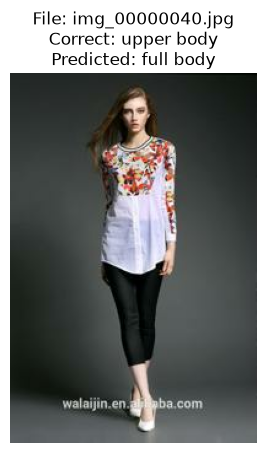

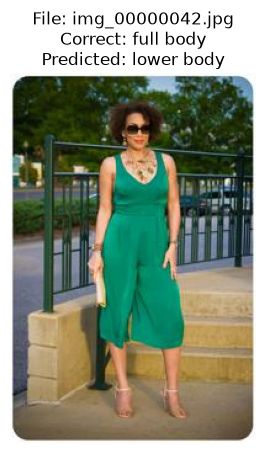

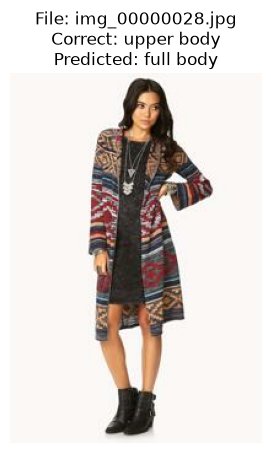

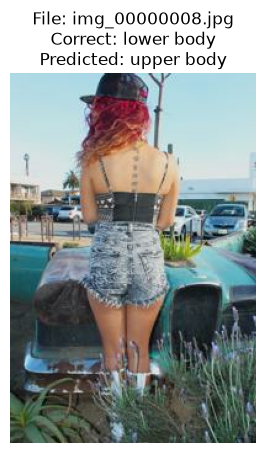

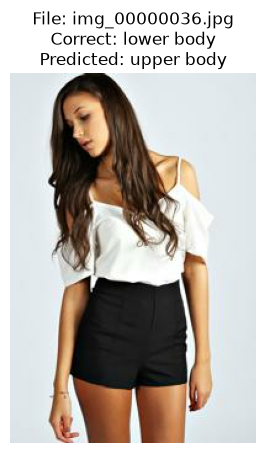

In [14]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# A dictionary to map category index back to a human-readable name.
# This is based on the data loading part of your notebook.
category_mapping = {
    0: 'upper body',
    1: 'lower body',
    2: 'full body'
}

misclassified_images = []

# It's good practice to not shuffle the validation set when debugging
# to have a consistent order. Your current code already does this.
# We will iterate through the validation dataset without shuffling.
# We also need the file paths, so we'll get them from the dataframe.
val_image_paths = val_df_with_category['img_name'].tolist()
val_labels = val_df_with_category['category_type_tf'].tolist()

# Create a new dataset with file paths to easily track misclassified images
val_ds_with_paths = tf.data.Dataset.from_tensor_slices(
    (val_image_paths, val_labels)
)

# Use the same loading and batching logic as your original val_ds
def load_image_and_path(path, label):
    img, label_out = load_image(path, label) # Re-use your existing load_image function
    return img, path, label_out

val_ds_with_paths = val_ds_with_paths.map(load_image_and_path, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_with_paths = val_ds_with_paths.batch(batch_size).prefetch(tf.data.AUTOTUNE)


print("Finding misclassified images...")
# Use the model you have loaded, e.g., model_loaded
# If you just trained a model and have it in a 'model' variable, you can use that.
# I'll use 'model' here as a placeholder for your trained model.
for images, paths, labels in val_ds_with_paths:
    predictions = model.predict(images, verbose=0)
    predicted_labels = tf.argmax(predictions, axis=1, output_type=tf.int32)

    # Compare predictions with true labels
    misclassified_mask = predicted_labels != labels
    
    misclassified_indices = tf.where(misclassified_mask).numpy().flatten()

    for index in misclassified_indices:
        misclassified_images.append({
            'image_path': paths.numpy()[index].decode('utf-8'),
            'true_label': labels.numpy()[index],
            'predicted_label': predicted_labels.numpy()[index]
        })

print(f"Found {len(misclassified_images)} misclassified images out of {len(val_image_paths)}.")

# Now, let's display some of the misclassified images
print("\nDisplaying a few misclassified images:")
num_to_display = min(len(misclassified_images), 5)

for i in range(num_to_display):
    info = misclassified_images[i]
    image_path = info['image_path']
    true_label_idx = info['true_label']
    predicted_label_idx = info['predicted_label']

    true_label_name = category_mapping.get(true_label_idx, "Unknown")
    predicted_label_name = category_mapping.get(predicted_label_idx, "Unknown")

    # Load and display the image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    
    plt.imshow(img.numpy())
    plt.title(f"File: {os.path.basename(image_path)}\nCorrect: {true_label_name}\nPredicted: {predicted_label_name}")
    plt.axis('off')
    plt.show()



In [13]:
labels

<tf.Tensor: shape=(64,), dtype=int32, numpy=
array([0, 0, 1, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 1, 0, 0, 2, 0, 0, 2, 2,
       0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2, 2, 1, 2, 2, 0, 0, 2, 2, 1,
       0, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 2, 0],
      dtype=int32)>

In [12]:
predicted_labels

<tf.Tensor: shape=(64,), dtype=int64, numpy=
array([2, 0, 1, 0, 0, 2, 2, 0, 2, 1, 0, 0, 2, 0, 1, 0, 0, 2, 0, 0, 2, 2,
       0, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0,
       0, 0, 0, 1, 2, 0, 2, 1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 2, 0])>